In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
from penaltyblog.models import DixonColesGoalModel
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# exemplo de jogos para ficar mais facil visualizar a execução do modelo
df = pd.DataFrame({
    'time-casa': ['Vasco',    'Fluminense', 'Vasco',      'Flamengo', 'Vasco',   'Flamengo',   'Flamengo', 'Botafogo',   'Fluminense', 'Botafogo', 'Botafogo', 'Fluminense'],
    'visitante': ['Flamengo', 'Botafogo',   'Fluminense', 'Botafogo', 'Botafogo', 'Fluminense', 'Vasco',    'Fluminense', 'Vasco',      'Flamengo', 'Vasco',   'Flamengo'],
    'gols-casa':      [1, 1, 1, 3, 0, 1, 2, 1, 1, 2, 2, 1],
    'gols-visitante': [2, 0, 0, 1, 2, 1, 0, 0, 0, 2, 1, 0],
})

df

,time-casa,visitante,gols-casa,gols-visitante
0,Vasco,Flamengo,1,2
1,Fluminense,Botafogo,1,0
2,Vasco,Fluminense,1,0
3,Flamengo,Botafogo,3,1
4,Vasco,Botafogo,0,2
5,Flamengo,Fluminense,1,1
6,Flamengo,Vasco,2,0
7,Botafogo,Fluminense,1,0
8,Fluminense,Vasco,1,0
9,Botafogo,Flamengo,2,2


In [4]:
# a distribuição Dixon-Coles é uma variação da distribuição de Poisson feita para esportes como Futebol, onde temos 2 valores e costumam ser pequenos
# Ele dá um peso maior para valores pequenos, principalmente os empates (0-0 e 1-1) que costumam ser subestimados. 
# Ele também abaixa um pouco as vitórias por pouco valor (1-0) que são hiper-valorizadas no Poisson, tornado-as muito provaveis mas menos que na versão tradicional
# Esse ajuste é feito com a constante rho, que é calculada a partir dos dados e devolvida pelo modelo
# Outras opções de distribuição que também se encaixam são a Zero Inflated Poisson e Binomial Negativa

modelo = DixonColesGoalModel(
  df["gols-casa"].to_numpy(copy=True),
  df["gols-visitante"].to_numpy(copy=True),
  df["time-casa"].to_numpy(copy=True), # to_numpy porque a biblioteca do modelo trabalha com números, não com dataframe e o copy é para que ele possa fazer alterações internas nos dados sem afetar os originais
  df["visitante"].to_numpy(copy=True),
) # params: gols do time da casa, gols do visitante, nome do time da casa, nome do visitante. Peso é opcional

modelo.fit() # define um valor de ataque e de defesa para cada time, uma constante de vantagem para o dono da casa
params = modelo.get_params()

params

{'attack_Botafogo': np.float64(1.4044516720995683),
 'attack_Flamengo': np.float64(1.5898664274773868),
 'attack_Fluminense': np.float64(0.540042362179757),
 'attack_Vasco': np.float64(0.4656395382432877),
 'defence_Botafogo': np.float64(-1.1563306569246286),
 'defence_Flamengo': np.float64(-1.2361007538765294),
 'defence_Fluminense': np.float64(-2.14802884092066),
 'defence_Vasco': np.float64(-1.1470584197726545),
 'home_advantage': np.float64(0.5094018474978182),
 'rho': np.float64(0.44863022022663335)}

In [5]:
# prevendo o vencedor de um jogo
previsao = modelo.predict("Flamengo", "Vasco")

previsao

Module: Penaltyblog

Class: FootballProbabilityGrid

Home Goal Expectation: 2.591
Away Goal Expectation: 0.463

Home Win: 0.8559
Draw: 0.0724
Away Win: 0.0717

In [6]:
print(f'Chance do mandante ganhar: {previsao.home_win}')
print(f'Chance de empate: {previsao.draw}')
print(f'Chance do visitante ganhar: {previsao.away_win}')

previsao.home_win+previsao.draw+previsao.away_win

Chance do mandante ganhar: 0.8558892630350008
Chance do mandante ganhar: 0.07236518062865126
Chance do mandante ganhar: 0.071745556336348


1.0

In [7]:
# ver a probabilidade de um placar exato
previsao.exact_score(2, 1) 

0.0732836194995141

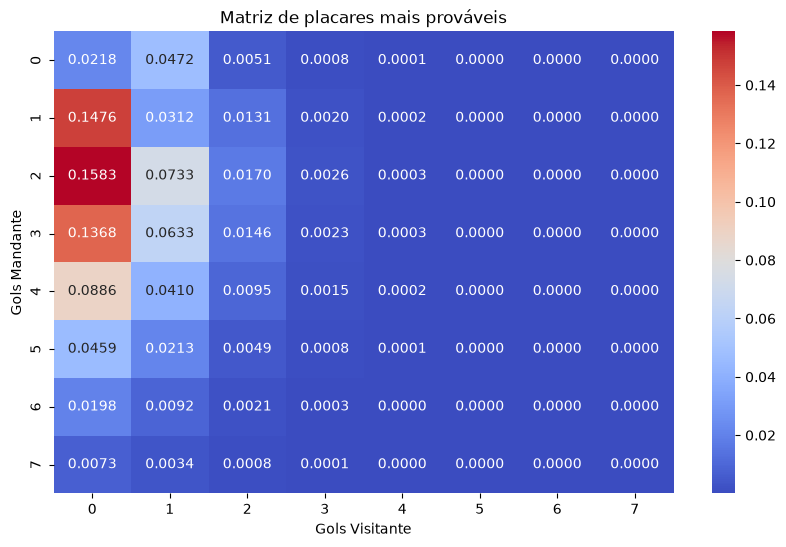

In [8]:
# prevendo o placar mais provavel
# cria matriz de placares prováveis. Precisa definir uma quantidade de gols maxima que um time pode fazer (ex: todas as combinações de 0-0 até MAX-MAX)
max_gols = 7
matriz_placar = np.zeros((max_gols+1, max_gols+1))
for gols_mandante in range(max_gols+1):
    for gols_visitante in range(max_gols+1):
        matriz_placar[gols_mandante, gols_visitante] = previsao.exact_score(gols_mandante, gols_visitante)


# Plot the heat map
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_placar, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Matriz de placares mais prováveis')
plt.xlabel("Gols Visitante")
plt.ylabel("Gols Mandante")
plt.show()

In [9]:
# pegando da matriz o valor mais provável
max_val = matriz_placar.max()
gols_mandante, gols_visitante = np.unravel_index(np.argmax(matriz_placar), matriz_placar.shape)

print(f"Placar mais provável: Flamengo {gols_mandante} x Vasco {gols_visitante}")

Placar mais provável: Flamengo 2 x Vasco 0


Chance do mandante ganhar: 0.2371035030678497
Chance de empate: 0.1497019300653509
Chance do visitante ganhar: 0.6131945668667995


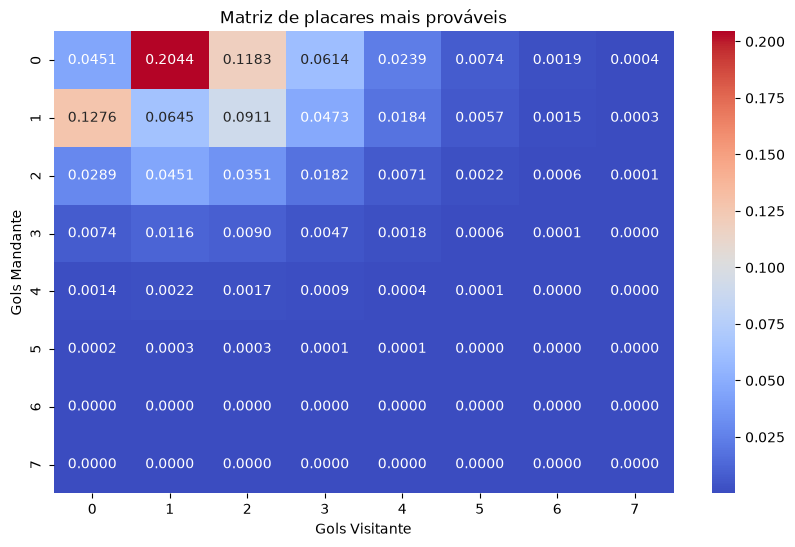

Placar mais provável: Vasco 0 x Flamengo 1


In [10]:
# prevendo o mesmo jogo mas mudando quem é o mandante
previsao = modelo.predict("Vasco", "Flamengo")
print(f'Chance do mandante ganhar: {previsao.home_win}')
print(f'Chance de empate: {previsao.draw}')
print(f'Chance do visitante ganhar: {previsao.away_win}')

max_gols = 7
matriz_placar = np.zeros((max_gols+1, max_gols+1))
for gols_mandante in range(max_gols+1):
    for gols_visitante in range(max_gols+1):
        matriz_placar[gols_mandante, gols_visitante] = previsao.exact_score(gols_mandante, gols_visitante)


# Plot the heat map
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_placar, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Matriz de placares mais prováveis')
plt.xlabel("Gols Visitante")
plt.ylabel("Gols Mandante")
plt.show()

max_val = matriz_placar.max()
gols_mandante, gols_visitante = np.unravel_index(np.argmax(matriz_placar), matriz_placar.shape)

print(f"Placar mais provável: Vasco {gols_mandante} x Flamengo {gols_visitante}")

In [11]:
# em caso de empate pega o resultado mais provável que não seja empate
times = ["Vasco", "Fluminense"]

previsao = modelo.predict(times[0], times[1])
max_gols = 7
matriz_placar = np.zeros((max_gols+1, max_gols+1))
for gols_mandante in range(max_gols+1):
    for gols_visitante in range(max_gols+1):
        matriz_placar[gols_mandante, gols_visitante] = previsao.exact_score(gols_mandante, gols_visitante)

# ordena os resultados do mais provavel ao menos
flat_indices = np.argsort(matriz_placar, axis=None)[::-1]
rows, cols = np.unravel_index(flat_indices, matriz_placar.shape)
sorted_indices = list(zip(rows, cols))

res_final = (None, None)
for res in sorted_indices:
    if(res[0] == res[1]): continue
    res_final = res
    break

res_final

(np.int64(0), np.int64(1))

In [12]:
# PARA FAZER PREVISÃO EM CAMPO NEUTRO TEM USAR MAIS PARAMS NO PREDICT

# reimprime os valores antigos para facilitar a comparação
previsao = modelo.predict("Flamengo", "Vasco")
print(f'Chance do mandante ganhar: {previsao.home_win}')
print(f'Chance de empate: {previsao.draw}')
print(f'Chance do visitante ganhar: {previsao.away_win}\n----------------')

# params: time1, time2, numMaximoGols, se é pra normalizar os resultados e o último se é em campo neutro (o ultimo que é o importante)
pred = modelo.predict("Flamengo", "Vasco", 7, True, True)
print(f'Chance do Flamengo ganhar em campo neutro: {pred.home_win}')
print(f'Chance de empate em campo neutro: {pred.draw}')
print(f'Chance do Vasco ganhar em campo neutro: {pred.away_win}\n-----------')

# troca a ordem para ver se as probabilidades mudam
pred2 = modelo.predict("Vasco", "Flamengo", 7, True, True)
prob_flamengo_igual = pred.home_win == pred2.away_win
prob_vasco_igual = pred.away_win == pred2.home_win
prob_empate_igual = pred.draw == pred2.draw
print(f'Probabilidade do flamengo ganhar é a mesma ao trocar a ordem? {prob_flamengo_igual}')
print(f'Probabilidade do vasco ganhar é a mesma ao trocar a ordem? {prob_vasco_igual}. DIFERENCA: {abs(pred.away_win - pred2.home_win)}')
print(f'Probabilidade do empate é a mesma ao trocar a ordem? {prob_empate_igual}')

Chance do mandante ganhar: 0.8558892630350008
Chance de empate: 0.07236518062865126
Chance do visitante ganhar: 0.071745556336348
----------------
Chance do Flamengo ganhar em campo neutro: 0.6883634477329443
Chance de empate em campo neutro: 0.161346299887723
Chance do Vasco ganhar em campo neutro: 0.1502902523793326
-----------
Probabilidade do flamengo ganhar é a mesma ao trocar a ordem? True
Probabilidade do vasco ganhar é a mesma ao trocar a ordem? False. DIFERENCA: 2.7755575615628914e-17
Probabilidade do empate é a mesma ao trocar a ordem? True
